In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
import glob
import os
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import seaborn as sns
import networkx as nx

In [3]:
dataset_labels = {
    "victor": "V&C",
    "portilla": "P&S",
    "gatys": "Gatys",
    "dtd": "DTD",
}

dataset_order = ["victor", "portilla", "gatys", "dtd"]

csv_files = sorted(glob.glob("*.csv"))

n_possible_answers = 3

dfs = []

for f in csv_files:
    tmp = pd.read_csv(f, sep=",", engine="python")

    tmp = tmp[
        ["category", "pair_condition", "odd_source", "ref_source", "accuracy"]
    ].copy()

    tmp["participant_file"] = os.path.basename(f)

    dfs.append(tmp)

df_humans = pd.concat(dfs, ignore_index=True)
n_trials_per_participatnt = len(df_humans)/len(csv_files)
chance = 1/n_possible_answers

print(f"Loaded {len(csv_files)} files")
print(f"Total trials: {len(df_humans)}")
print(chance)

Loaded 53 files
Total trials: 73321
0.3333333333333333


In [5]:
df_agg = df_humans.groupby(["pair_condition","participant_file"]).aggregate('mean')
#df_agg_participant = df_humans.groupby(["participant_file"]).aggregate('mean') #from here plot the distrib
df_agg_participant = (
    df_humans
    .groupby("participant_file", as_index=False)["accuracy"]
    .mean()
)

df_agg_participant = df_agg_participant.drop(index=[49, 50]).reset_index(drop=True)

df_agg_participant

/tmp/ipykernel_27412/386011522.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_agg = df_humans.groupby(["pair_condition","participant_file"]).aggregate('mean')


,participant_file,accuracy
0,5c4e5f2ae5f00f0001542748_behavioral_textures_2...,0.553901
1,613b36b5240057d01caa5546_behavioral_textures_2...,0.519149
2,61629ab0967be4034732c1cc_behavioral_textures_2...,0.580851
3,64835b36bbe37277bdaee2c4_behavioral_textures_2...,0.541135
4,6499bcd55da5a766c49f8493_behavioral_textures_2...,0.570922
5,678d265eb819fdb2c5a362f9_behavioral_textures_2...,0.499291
6,68e686aa63c9d127e4717997_behavioral_textures_2...,0.546099
7,69318afe3bbdec5adc573ab3_behavioral_textures_2...,0.573759
8,6967874b1a8d2f72958a3582_behavioral_textures_2...,0.583688
9,69763a1bb7aa938df9bcb713_behavioral_textures_2...,0.585106


In [6]:
df_agg_participant = df_agg_participant.copy()
df_agg_participant = df_agg_participant.reset_index(drop=True)

df_agg_participant["participant_index"] = df_agg_participant.index
df_agg_participant

,participant_file,accuracy,participant_index
0,5c4e5f2ae5f00f0001542748_behavioral_textures_2...,0.553901,0
1,613b36b5240057d01caa5546_behavioral_textures_2...,0.519149,1
2,61629ab0967be4034732c1cc_behavioral_textures_2...,0.580851,2
3,64835b36bbe37277bdaee2c4_behavioral_textures_2...,0.541135,3
4,6499bcd55da5a766c49f8493_behavioral_textures_2...,0.570922,4
5,678d265eb819fdb2c5a362f9_behavioral_textures_2...,0.499291,5
6,68e686aa63c9d127e4717997_behavioral_textures_2...,0.546099,6
7,69318afe3bbdec5adc573ab3_behavioral_textures_2...,0.573759,7
8,6967874b1a8d2f72958a3582_behavioral_textures_2...,0.583688,8
9,69763a1bb7aa938df9bcb713_behavioral_textures_2...,0.585106,9


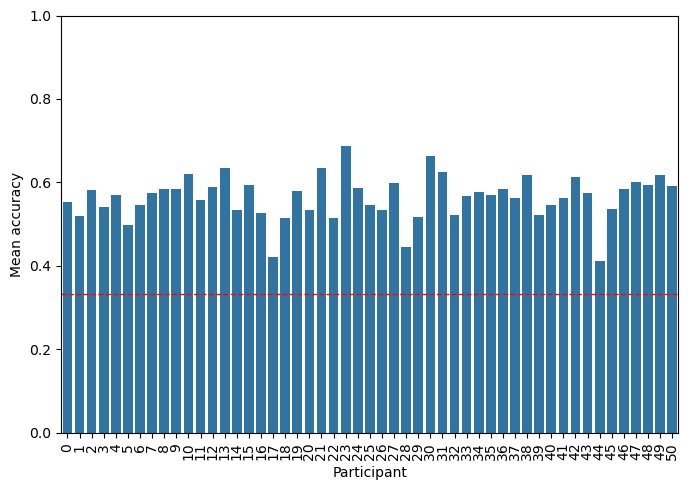

In [7]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_agg_participant,
    x="participant_index",
    y="accuracy",
)
plt.axhline(chance, linestyle="--", linewidth=1, label="chance", color="red")
plt.xticks(rotation=90)
plt.xlabel("Participant")
plt.ylabel("Mean accuracy")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("accuracy_by_participant.png", dpi=300)
plt.show()

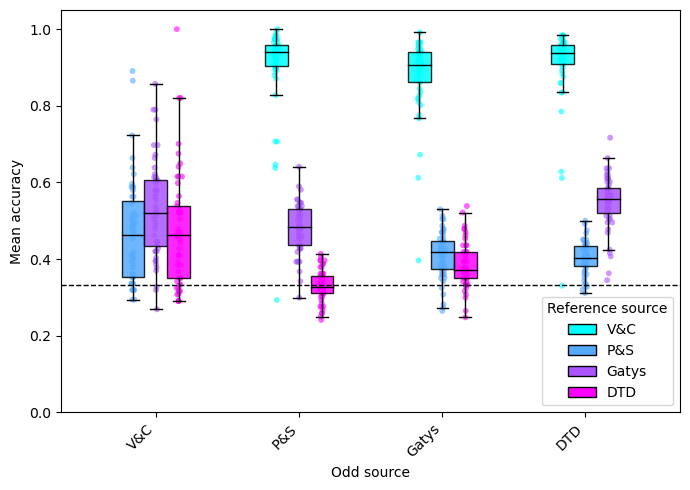

In [8]:
df_plot = (
    df_humans
    .groupby(["participant_file", "odd_source", "ref_source"], as_index=False)["accuracy"]
    .mean()
)

source_order = ["victor", "portilla", "gatys", "dtd"]

colors = plt.cm.cool(np.linspace(0, 1, len(source_order)))
palette = dict(zip(source_order, colors))

fig, ax = plt.subplots(figsize=(7, 5))

box_width = 0.16
offsets = [-box_width, 0.0, box_width]

for i, odd in enumerate(source_order):

    refs = [r for r in source_order if r != odd]

    for j, ref in enumerate(refs):
        sub = df_plot[
            (df_plot["odd_source"] == odd) &
            (df_plot["ref_source"] == ref)
        ]

        pos = i + offsets[j]

        ax.boxplot(
            sub["accuracy"],
            positions=[pos],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=palette[ref], edgecolor="black", alpha=0.85),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )

        #individual participants
        jitter = np.random.normal(0, 0.008, size=len(sub))
        ax.scatter(
            np.full(len(sub), pos) + jitter,
            sub["accuracy"],
            color=palette[ref],
            edgecolor="none",
            alpha=0.6,
            s=18,
        )

ax.axhline(chance, linestyle="--", linewidth=1, color="black")

ax.set_xticks(range(len(source_order)))
ax.set_xticklabels(
    [dataset_labels[x] for x in source_order],
    rotation=45,
    ha="right"
)

ax.set_xlabel("Odd source")
ax.set_ylabel("Mean accuracy")
ax.set_ylim(0, 1.05)

legend_handles = [
    Patch(
        facecolor=palette[s],
        edgecolor="black",
        label=dataset_labels[s]
    )
    for s in source_order
]

ax.legend(
    handles=legend_handles,
    title="Reference source",
    loc="lower right",
    frameon=True,
)

plt.tight_layout()
plt.savefig("accuracy_by_odd_and_ref_source.png", dpi=300)
plt.show()

In [10]:
df_humans_corr_mean = (
    df_humans
    .groupby(["odd_source", "ref_source"], as_index=False)["accuracy"]
    .mean()
)

dataset_labels = {
    "dtd": "DTD",
    "gatys": "G",
    "portilla": "P&S",
    "victor": "V&C",
}

dataset_order = ["dtd", "gatys", "portilla", "victor"]

pos = {
    "dtd":      (-1.0, -1.0),
    "gatys":   (-1.0,  1.0),
    "portilla": (1.0,  1.0),
    "victor":   (1.0, -1.0),
}

df_humans_corr_mean

,odd_source,ref_source,accuracy
0,dtd,gatys,0.548162
1,dtd,portilla,0.402585
2,dtd,victor,0.908296
3,gatys,dtd,0.382972
4,gatys,portilla,0.409928
5,gatys,victor,0.882294
6,portilla,dtd,0.330736
7,portilla,gatys,0.481427
8,portilla,victor,0.905836
9,victor,dtd,0.466557


In [11]:
df_humans_undir = df_humans_corr_mean.copy()

df_humans_undir["X"] = df_humans_undir[["odd_source", "ref_source"]].min(axis=1)
df_humans_undir["Y"] = df_humans_undir[["odd_source", "ref_source"]].max(axis=1)

df_humans_undir = (
    df_humans_undir
    .groupby(["X", "Y"], as_index=False)["accuracy"]
    .mean()
)

df_humans_undir

,X,Y,accuracy
0,dtd,gatys,0.465567
1,dtd,portilla,0.366661
2,dtd,victor,0.687427
3,gatys,portilla,0.445677
4,gatys,victor,0.707146
5,portilla,victor,0.686515


In [13]:
df = pd.read_csv("/your/across_data/ii_results/path", 
                 sep=r"\s+", header=None,
                 names=["model", "X", "Y", "ave"])
df = df.iloc[1:]
df["pair"] = df.apply(lambda r: tuple(sorted([r["X"], r["Y"]])), axis=1)
#print(df["pair"])
df_unique = df.drop_duplicates(subset=["model", "pair"]).copy()

df_unique = df_unique[
    (df_unique["X"] != "noise") &
    (df_unique["Y"] != "noise")
].copy()

df_unique_models = df_unique.drop(columns=["pair"]).copy()
df_unique_models = df_unique_models.reset_index(drop=True)

print(df_unique_models)

    model         X         Y   ave
0    clip       dtd     gatys  0.02
1    clip       dtd  portilla  0.07
2    clip       dtd    victor  0.70
3    clip     gatys  portilla  0.09
4    clip     gatys    victor  0.61
5    clip  portilla    victor  0.58
6    dino       dtd     gatys  0.01
7    dino       dtd  portilla  0.05
8    dino       dtd    victor  0.70
9    dino     gatys  portilla  0.05
10   dino     gatys    victor  0.65
11   dino  portilla    victor  0.60
12   igpt       dtd     gatys  0.02
13   igpt       dtd  portilla  0.15
14   igpt       dtd    victor  0.75
15   igpt     gatys  portilla  0.28
16   igpt     gatys    victor  0.77
17   igpt  portilla    victor  0.74
18  vgg19       dtd     gatys  0.75
19  vgg19       dtd  portilla  0.83
20  vgg19       dtd    victor  0.84
21  vgg19     gatys  portilla  0.73
22  vgg19     gatys    victor  0.86
23  vgg19  portilla    victor  0.95


In [14]:
# -----------------------------
# Prepare model data
# -----------------------------
df_model_corr = df_unique_models.copy()
df_model_corr["ave"] = df_model_corr["ave"].astype(float)

# make sure X,Y are sorted consistently
df_model_corr["X_tmp"] = df_model_corr[["X", "Y"]].min(axis=1)
df_model_corr["Y_tmp"] = df_model_corr[["X", "Y"]].max(axis=1)

df_model_corr["X"] = df_model_corr["X_tmp"]
df_model_corr["Y"] = df_model_corr["Y_tmp"]

df_model_corr = df_model_corr.drop(columns=["X_tmp", "Y_tmp"])


# -----------------------------
# Prepare human data
# -----------------------------
df_human_corr = df_humans_undir.copy()
df_human_corr["accuracy"] = df_human_corr["accuracy"].astype(float)

# make sure X,Y are sorted consistently
df_human_corr["X_tmp"] = df_human_corr[["X", "Y"]].min(axis=1)
df_human_corr["Y_tmp"] = df_human_corr[["X", "Y"]].max(axis=1)

df_human_corr["X"] = df_human_corr["X_tmp"]
df_human_corr["Y"] = df_human_corr["Y_tmp"]

df_human_corr = df_human_corr.drop(columns=["X_tmp", "Y_tmp"])


# -----------------------------
# Merge model and human data
# -----------------------------
df_corr = df_model_corr.merge(
    df_human_corr[["X", "Y", "accuracy"]],
    on=["X", "Y"],
    how="inner"
)

df_corr

,model,X,Y,ave,accuracy
0,clip,dtd,gatys,0.02,0.465567
1,dino,dtd,gatys,0.01,0.465567
2,igpt,dtd,gatys,0.02,0.465567
3,vgg19,dtd,gatys,0.75,0.465567
4,clip,dtd,portilla,0.07,0.366661
5,dino,dtd,portilla,0.05,0.366661
6,igpt,dtd,portilla,0.15,0.366661
7,vgg19,dtd,portilla,0.83,0.366661
8,clip,dtd,victor,0.70,0.687427
9,dino,dtd,victor,0.70,0.687427


In [15]:
model_order = ["clip", "dino", "igpt", "vgg19"]

results = []

for model in model_order:
    sub = df_corr[df_corr["model"] == model].copy()

    x = sub["accuracy"].values
    y = sub["ave"].values

    pearson_r, pearson_p = pearsonr(x, y)

    results.append({
        "model": model,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "n_pairs": len(sub),
    })

df_results = pd.DataFrame(results)
df_results

,model,pearson_r,pearson_p,n_pairs
0,clip,0.955926,0.002871,6
1,dino,0.963057,0.002022,6
2,igpt,0.936344,0.005949,6
3,vgg19,0.664769,0.149733,6


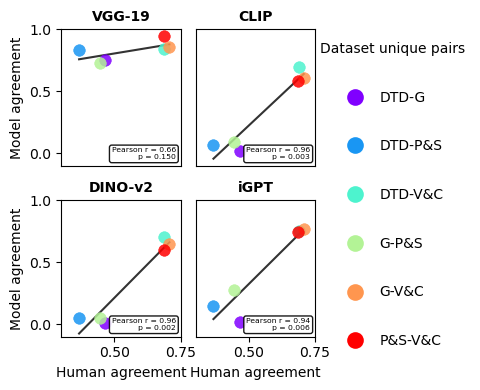

In [38]:
dataset_labels = {
    "dtd": "DTD",
    "gatys": "G",
    "portilla": "P&S",
    "victor": "V&C",
}

model_labels = {
    "clip": "CLIP",
    "dino": "DINO-v2",
    "igpt": "iGPT",
    "vgg19": "VGG-19",
}

model_order = ["vgg19", "clip", "dino", "igpt"]

pair_order = [
    ("dtd", "gatys"),
    ("dtd", "portilla"),
    ("dtd", "victor"),
    ("gatys", "portilla"),
    ("gatys", "victor"),
    ("portilla", "victor"),
]

pair_colors = plt.cm.rainbow(np.linspace(0, 1, len(pair_order)))
pair_palette = dict(zip(pair_order, pair_colors))

pair_labels = {
    pair: f"{dataset_labels[pair[0]]}-{dataset_labels[pair[1]]}"
    for pair in pair_order
}

fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, model) in enumerate(zip(axes, model_order)):

    row_i = i // 2
    col_i = i % 2

    sub = df_corr[df_corr["model"] == model].copy()

    x = sub["accuracy"].values
    y = sub["ave"].values

    r, p = pearsonr(x, y)


    for _, row in sub.iterrows():

        pair = tuple(sorted((row["X"], row["Y"])))

        ax.scatter(
            row["accuracy"],
            row["ave"],
            s=70,
            alpha=0.85,
            color=pair_palette[pair],
            linewidth=0.4,
            zorder=3
        )

    m, b = np.polyfit(x, y, 1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = m * x_fit + b

    ax.plot(
        x_fit,
        y_fit,
        linewidth=1.5,
        color="black",
        alpha=0.8,
        zorder=2
    )

    ax.set_title(
        model_labels[model],
        fontsize=10,
        fontweight="bold",
        color="black"
    )

    ax.text(
        0.96,
        0.04,
        f"Pearson r = {r:.2f}\np = {p:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=5.5,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3",
            alpha=0.9
        ),
        zorder=5
    )

    ax.set_xlim(0.3, 0.75)
    ax.set_ylim(-0.1, 1.0)
    
    # x axis only on second row
    if row_i == 0:
        ax.set_xlabel("")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    else:
        ax.set_xlabel("Human agreement")
    
    # y axis only on first column
    if col_i == 1:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)
    else:
        ax.set_ylabel("Model agreement")

# -----------------------------
# External pair legend
# -----------------------------
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markersize=12,                 # larger palette points
        markerfacecolor=pair_palette[pair],
        markeredgecolor="none",        # remove marker edge
        markeredgewidth=0,
        label=pair_labels[pair]
    )
    for pair in pair_order
]

fig.legend(
    handles=legend_handles,
    title="Dataset unique pairs",
    loc="center left",
    bbox_to_anchor=(0.82, 0.5),
    frameon=False,                    
    labelspacing=2.5,               
    handletextpad=0.8,
    borderaxespad=0.0,
    fontsize=10,
    title_fontsize=10
)


plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.savefig("human_model_correlations.png", dpi=300, bbox_inches="tight")
plt.show()